IMPORTING THE DEPENDENCIES

In [93]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


DATA COLLECTION & PROCESSING

In [94]:
# load the data from csv file to pandas dataframe
titanic_data=pd.read_csv("train.csv")

In [95]:
# printing the first 5 rows of the dataframe
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [96]:
# number of rows and Columns
titanic_data.shape

(891, 12)

In [97]:
# getting some informations about the data
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [98]:
# check the number of missing values in each column
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

HANDLING THE MISSING VALUES

In [99]:
# drop the "Cabin" column from the dataframe
titanic_data = titanic_data.drop(columns='Cabin', axis=1)

In [100]:
# replacing the missing values in "Age" column with mean value
titanic_data['Age'] = titanic_data['Age'].fillna(
    titanic_data['Age'].mean()
)

In [101]:
# finding the mode value of "Embarked" column
print(titanic_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [102]:
# replacing the missing values in "Embarked" column with mode value
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(
    titanic_data['Embarked'].mode()[0]
)

In [103]:
# check the number of missing values in each column
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

 DATA ANALYSIS

In [104]:
# getting some statistical measures about the data
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [105]:
# finding the number of people survived and not survived
# 0 means not survived
# 1 means survived
titanic_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [106]:
# applying seaborn default theme for better visualization
sns.set()

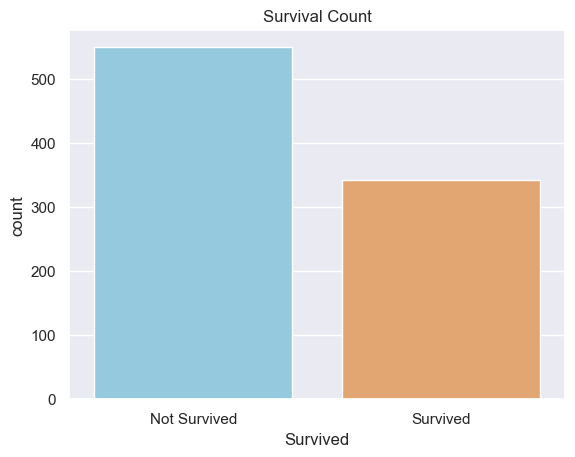

In [107]:
# making a count plot for "Survived" column
sns.countplot(
    x='Survived',
    data=titanic_data,
    hue='Survived',
    palette=['skyblue', 'sandybrown'],
    legend=False
)

plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.title('Survival Count')
plt.show()
plt.show()

In [108]:
# counting the number of male and female passengers
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

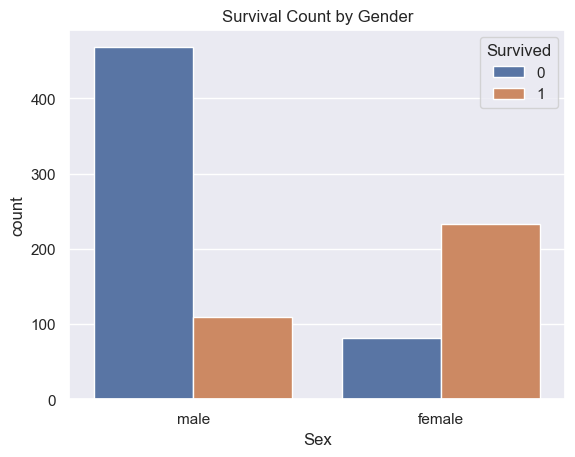

In [109]:
# number of survivors gender wise
sns.countplot(
    x='Sex',
    hue='Survived',
    data=titanic_data
)

plt.title('Survival Count by Gender')
plt.show()

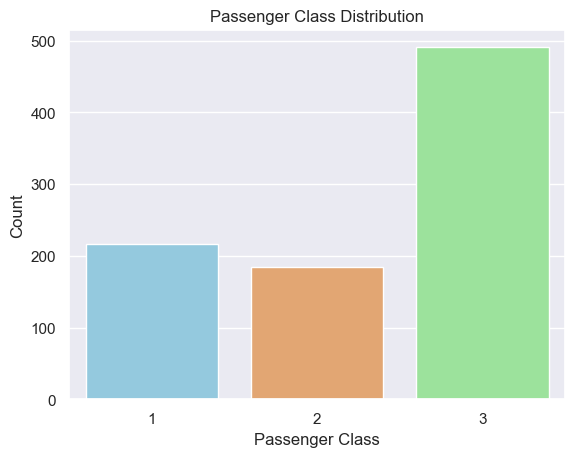

In [110]:
# making a count plot for "Pclass" column
sns.countplot(
    x='Pclass',
    data=titanic_data,
    hue='Pclass',
    palette=['skyblue', 'sandybrown', 'lightgreen'],
    legend=False
)

plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

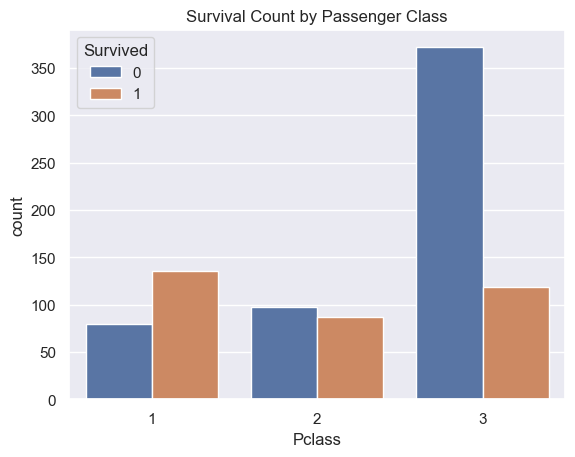

In [111]:
# number of survivors based on passenger class
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=titanic_data
)

plt.title('Survival Count by Passenger Class')
plt.show()

Encoding the Categorical Columns

In [112]:
# counting the number of male and female passengers
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [113]:
titanic_data['Embarked'].map({
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}).value_counts()

Embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [114]:
# converting categorical columns into numerical values
titanic_data['Sex'] = titanic_data['Sex'].map({
    'male': 0,
    'female': 1
})

titanic_data['Embarked'] = titanic_data['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [115]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


SEPARATING FEATURE & TARGET

In [116]:
# separating features and target variable
# separating features and target
X = titanic_data.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Survived'],
    axis=1
)

Y = titanic_data['Survived']

In [117]:
print(X)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]


In [118]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


SPLITTING THE DATA INTO TRAINING DATA &TEST DATA

In [119]:
# splitting the dataset into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

In [120]:
print(X.shape, X_train.shape, X_test.shape)

(891, 7) (712, 7) (179, 7)


MODEL TRAINING

Logistic Regression


In [121]:
model = LogisticRegression(max_iter=1000)

In [122]:
# training the Logistic Regression model with training data
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


MODEL EVALUATION


Accuracy Score

In [123]:
# accuracy on training data
X_train_prediction = model.predict(X_train)

In [124]:
print(X_train_prediction)

[0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0
 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 0
 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 1
 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0
 0 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 0 0 1 0 1 1 0 

In [125]:
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Accuracy score of training data : ', training_data_accuracy)

Accuracy score of training data :  0.8089887640449438


In [126]:
# accuracy on test data
X_test_prediction = model.predict(X_test)

In [127]:
print(X_test_prediction)

[0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0
 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 0 0 0
 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 0
 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 0]


In [129]:
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy score of test data : ', test_data_accuracy)

Accuracy score of test data :  0.7821229050279329


In [130]:
# importing confusion matrix
from sklearn.metrics import confusion_matrix

# creating confusion matrix for test data
cm = confusion_matrix(Y_test, X_test_prediction)

# displaying the confusion matrix
print(cm)

[[91  9]
 [30 49]]


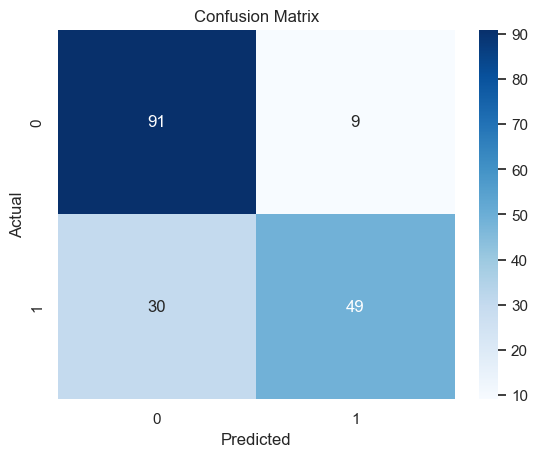

In [131]:
# plotting the confusion matrix as a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# adding labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# displaying the plot
plt.show()

In [132]:
# importing classification report
from sklearn.metrics import classification_report

# generating the classification report
report = classification_report(Y_test, X_test_prediction)

# displaying the report
print(report)

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       100
           1       0.84      0.62      0.72        79

    accuracy                           0.78       179
   macro avg       0.80      0.77      0.77       179
weighted avg       0.79      0.78      0.78       179



In [133]:
# input data:
# Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

input_data = (3, 0, 22, 1, 0, 7.25, 0)

# converting input data into numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshaping the array for a single prediction
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# making prediction
prediction = model.predict(input_data_reshaped)

# displaying the prediction result
if prediction[0] == 0:
    print("The person did not survive")
else:
    print("The person survived")

The person did not survive


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [134]:
# importing pickle library
import pickle

# file name for saving the model
filename = 'titanic_model.sav'

# saving the trained model
pickle.dump(model, open(filename, 'wb'))

print("Model saved successfully!")

Model saved successfully!


In [135]:
# loading the saved model
loaded_model = pickle.load(open('titanic_model.sav', 'rb'))